In [1]:
!git clone https://github.com/lasyaa417/MGT-3078-Index-Arbitrage-Simulation.git
%cd MGT-3078-Index-Arbitrage-Simulation
!ls


C:\Users\14046\Downloads\MGT-3078-Index-Arbitrage-Simulation


Cloning into 'MGT-3078-Index-Arbitrage-Simulation'...
'ls' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
os.listdir()


['.git',
 'dow_10_factors_2009.csv',
 'dow_10_factors_2010.csv',
 'dow_10_factors_2011.csv',
 'dow_10_factors_2012.csv',
 'dow_10_factors_2013.csv',
 'dow_10_factors_2014.csv',
 'dow_10_factors_2015.csv',
 'dow_10_factors_2016.csv',
 'dow_10_factors_2020_to_2025.csv',
 'dow_factor_inputs_2009_2016.csv',
 'dow_factor_inputs_2020_2025.csv',
 'README.md',
 'stat_arb_updated.ipynb']

forward return

In [4]:
import pandas as pd

df = pd.read_csv("dow_factor_inputs_2009_2016.csv")

# If your file has a date column, convert it
df["date"] = pd.to_datetime(df["date"])

# Sort by stock and date
df = df.sort_values(["symbol", "date"]).copy()

# Compute next-period return
df["forward_return"] = df.groupby("symbol")["Adj Close"].shift(-1) / df["Adj Close"] - 1

# Look at the result
df[["date", "symbol", "Adj Close", "forward_return"]].head(10)


,date,symbol,Adj Close,forward_return
0,2007-01-03,AA,57.564400,-0.007501
34,2007-01-04,AA,57.132633,-0.012024
68,2007-01-05,AA,56.445698,-0.009736
102,2007-01-08,AA,55.896164,0.001405
136,2007-01-09,AA,55.974693,0.059957
170,2007-01-10,AA,59.330795,0.007940
204,2007-01-11,AA,59.801853,0.010502
238,2007-01-12,AA,60.429882,-0.006821
272,2007-01-16,AA,60.017704,-0.001635
306,2007-01-17,AA,59.919601,-0.007534


 Load the 2015 factor file and merge

In [5]:
factors = pd.read_csv("dow_10_factors_2015.csv")
factors["date"] = pd.to_datetime(factors["date"])

merged = factors.merge(
    df[["date", "symbol", "forward_return"]],
    on=["date", "symbol"],
    how="left"
)

merged.head()


,date,symbol,pull_symbol,in_dow,RSI_14,Dist_MA20,Bollinger_Band_Width,ZScore_MA20,Mom_12M_Refined,MACD,Dollar_Volume,Volume_Shock,MFI_14,Historical_Volatility_20D,Chaikin_Oscillator,forward_return
0,2015-01-02,AXP,AXP,1,53.514821,0.003734,0.069325,0.215419,0.051009,0.632023,1.926605e+08,-0.320945,54.121856,0.201614,-1.523911e+06,-0.026446
1,2015-01-02,BA,BA,1,53.943263,0.014953,0.114817,0.520935,-0.009527,0.615910,4.880669e+08,-0.047112,75.307023,0.221527,-1.197446e+06,-0.006926
2,2015-01-02,CAT,CAT,1,38.718944,-0.012616,0.116677,-0.432526,0.136747,-1.271710,2.605825e+08,-0.310482,50.288735,0.213654,-1.758789e+06,-0.052787
3,2015-01-02,CSCO,CSCO,1,57.369477,0.007789,0.090759,0.343301,0.294882,0.315434,4.494491e+08,-0.125928,56.799364,0.181856,-7.984601e+06,-0.019920
4,2015-01-02,CVX,CVX,1,53.339110,0.031170,0.162595,0.766804,-0.048769,0.123656,4.101400e+08,-0.400951,63.965273,0.309594,4.169888e+06,-0.039972


Define the factor columns

In [6]:
factor_cols = [
    "RSI_14",
    "Dist_MA20",
    "Bollinger_Band_Width",
    "ZScore_MA20",
    "Mom_12M_Refined",
    "MACD",
    "Dollar_Volume",
    "Volume_Shock",
    "MFI_14",
    "Historical_Volatility_20D",
    "Chaikin_Oscillator"
]


Compute z-scores and exclude outliers

In [7]:
for col in factor_cols:
    z_col = col + "_z"
    merged[z_col] = merged.groupby("date")[col].transform(
        lambda x: (x - x.mean()) / x.std(ddof=0)
    )
    merged[z_col] = merged[z_col].clip(-2, 2)


merged[["date", "symbol"] + [col + "_z" for col in factor_cols]].head()


,date,symbol,RSI_14_z,Dist_MA20_z,Bollinger_Band_Width_z,ZScore_MA20_z,Mom_12M_Refined_z,MACD_z,Dollar_Volume_z,Volume_Shock_z,MFI_14_z,Historical_Volatility_20D_z,Chaikin_Oscillator_z
0,2015-01-02,AXP,0.362992,0.083592,-0.607982,0.244008,-0.639580,0.539085,-1.044599,-0.681997,-0.103936,-0.029646,0.410222
1,2015-01-02,BA,0.432859,1.004280,1.048319,0.793367,-1.088115,0.512679,0.380672,1.040433,2.000000,0.383595,0.455562
2,2015-01-02,CAT,-2.000000,-1.258103,1.116038,-0.921086,-0.004306,-2.000000,-0.716890,-0.616189,-0.511253,0.220213,0.377603
3,2015-01-02,CSCO,0.991572,0.416428,0.172417,0.473956,1.167380,0.020270,0.194349,0.544671,0.180582,-0.439674,-0.487034
4,2015-01-02,CVX,0.334339,2.000000,2.000000,1.235473,-1.378875,-0.294012,0.004692,-1.185246,0.942047,2.000000,1.200974


Compute IC by factor by date


In [8]:
ic_results = []

for col in factor_cols:
    z_col = col + "_z"

    daily_ic = merged.groupby("date").apply(
        lambda x: x[[z_col, "forward_return"]].dropna().corr(method="spearman").iloc[0, 1]

        if len(x[[z_col, "forward_return"]].dropna()) > 1 else np.nan
    )

    for dt, ic_val in daily_ic.items():
        ic_results.append({
            "date": dt,
            "factor": col,
            "IC": ic_val
        })

ic_df = pd.DataFrame(ic_results)
ic_df.head()


C:\Users\14046\AppData\Local\Temp\ipykernel_16752\3731072337.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = merged.groupby("date").apply(
C:\Users\14046\AppData\Local\Temp\ipykernel_16752\3731072337.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = merged.groupby("date").apply(
C:\Users\14046\AppData\Local\Temp\ipykernel_16752\3731072337.py:6: DeprecationWarning: DataFrameGroupB

,date,factor,IC
0,2015-01-02,RSI_14,-0.260067
1,2015-01-05,RSI_14,0.258287
2,2015-01-06,RSI_14,0.194015
3,2015-01-07,RSI_14,-0.187542
4,2015-01-08,RSI_14,0.109912


Compute ICIR

In [9]:
icir_df = ic_df.groupby("factor")["IC"].agg(["mean", "std"]).reset_index()
icir_df["ICIR"] = icir_df["mean"] / icir_df["std"]
icir_df["abs_ICIR"] = icir_df["ICIR"].abs()
icir_df = icir_df.sort_values("abs_ICIR", ascending=False)

icir_df



,factor,mean,std,ICIR,abs_ICIR
1,Chaikin_Oscillator,-0.036528,0.211923,-0.172366,0.172366
5,MACD,0.027696,0.239428,0.115676,0.115676
7,Mom_12M_Refined,0.033383,0.289699,0.115235,0.115235
4,Historical_Volatility_20D,-0.021348,0.243049,-0.087835,0.087835
0,Bollinger_Band_Width,-0.013649,0.227081,-0.060105,0.060105
3,Dollar_Volume,-0.011808,0.206817,-0.057096,0.057096
2,Dist_MA20,-0.014080,0.256659,-0.054858,0.054858
10,ZScore_MA20,-0.005085,0.241937,-0.021016,0.021016
6,MFI_14,-0.003632,0.230696,-0.015745,0.015745
8,RSI_14,0.001150,0.246363,0.004670,0.004670


Pick the best 3 factors

In [10]:
top_3_factors = icir_df.head(3)["factor"].tolist()
top_3_factors


['Chaikin_Oscillator', 'MACD', 'Mom_12M_Refined']

Flip negative factors for composite

In [11]:
mean_ic_map = ic_df.groupby("factor")["IC"].mean().to_dict()

for factor in top_3_factors:
    z_col = factor + "_z"
    aligned_col = factor + "_aligned_z"

    if mean_ic_map[factor] < 0:
        merged[aligned_col] = -1 * merged[z_col]
    else:
        merged[aligned_col] = merged[z_col]

merged[["date", "symbol"] + [factor + "_aligned_z" for factor in top_3_factors]].head()


,date,symbol,Chaikin_Oscillator_aligned_z,MACD_aligned_z,Mom_12M_Refined_aligned_z
0,2015-01-02,AXP,-0.410222,0.539085,-0.639580
1,2015-01-02,BA,-0.455562,0.512679,-1.088115
2,2015-01-02,CAT,-0.377603,-2.000000,-0.004306
3,2015-01-02,CSCO,0.487034,0.020270,1.167380
4,2015-01-02,CVX,-1.200974,-0.294012,-1.378875


Build composite z-score

In [12]:
aligned_cols = [factor + "_aligned_z" for factor in top_3_factors]
merged["composite_zscore"] = merged[aligned_cols].mean(axis=1)

merged[["date", "symbol", "composite_zscore"] + aligned_cols].head()



,date,symbol,composite_zscore,Chaikin_Oscillator_aligned_z,MACD_aligned_z,Mom_12M_Refined_aligned_z
0,2015-01-02,AXP,-0.170239,-0.410222,0.539085,-0.639580
1,2015-01-02,BA,-0.343666,-0.455562,0.512679,-1.088115
2,2015-01-02,CAT,-0.793970,-0.377603,-2.000000,-0.004306
3,2015-01-02,CSCO,0.558228,0.487034,0.020270,1.167380
4,2015-01-02,CVX,-0.957953,-1.200974,-0.294012,-1.378875


### Multi-Year Factor Analysis (2009-2016)

In [13]:
import warnings
warnings.filterwarnings("ignore")
import os

years_to_analyze = range(2009, 2017)
yearly_icir_dataframes = {}
output_dir = "yearly_icir_results"
os.makedirs(output_dir, exist_ok=True)

for year in years_to_analyze:
    print(f"Processing year: {year}")

    # Load yearly factor data
    yearly_factors_filename = f"dow_10_factors_{year}.csv"
    yearly_factors = pd.read_csv(yearly_factors_filename)
    yearly_factors["date"] = pd.to_datetime(yearly_factors["date"])

    # Merge with forward_return from the pre-loaded df
    # Note: 'df' was loaded from "dow_factor_inputs_2009_2016.csv" and contains forward_return for all these years.
    yearly_merged = yearly_factors.merge(
        df[df['date'].dt.year == year][["date", "symbol", "forward_return"]],
        on=["date", "symbol"],
        how="left"
    )

    # Compute z-scores for the current year's merged data
    for col in factor_cols:
        z_col = col + "_z"
        yearly_merged[z_col] = yearly_merged.groupby("date")[col].transform(
            lambda x: (x - x.mean()) / x.std(ddof=0)
        )
        yearly_merged[z_col] = yearly_merged[z_col].clip(-2, 2)

    # Compute IC by factor by date for the current year
    yearly_ic_results = []
    for col in factor_cols:
        z_col = col + "_z"
        daily_ic = yearly_merged.groupby("date").apply(
            lambda x: x[[z_col, "forward_return"]].dropna().corr(method="spearman").iloc[0, 1]
            if len(x[[z_col, "forward_return"]].dropna()) > 1 else np.nan
        )

        for dt, ic_val in daily_ic.items():
            yearly_ic_results.append({
                "date": dt,
                "factor": col,
                "IC": ic_val
            })

    yearly_ic_df = pd.DataFrame(yearly_ic_results)

    # Compute ICIR for the current year
    yearly_icir_df = yearly_ic_df.groupby("factor")["IC"].agg(["mean", "std"]).reset_index()
    yearly_icir_df["ICIR"] = yearly_icir_df["mean"] / yearly_icir_df["std"]
    yearly_icir_df["abs_ICIR"] = yearly_icir_df["ICIR"].abs()
    yearly_icir_df["year"] = year

    # Store the yearly ICIR DataFrame in the dictionary
    yearly_icir_dataframes[year] = yearly_icir_df

    # Save the yearly ICIR DataFrame to a CSV file
    output_filename = os.path.join(output_dir, f"icir_results_{year}.csv")
    yearly_icir_df.to_csv(output_filename, index=False)
    print(f"Saved ICIR results for {year} to {output_filename}")

print("All yearly ICIR results have been saved to individual CSV files and stored in 'yearly_icir_dataframes' dictionary.")

Processing year: 2009
Saved ICIR results for 2009 to yearly_icir_results\icir_results_2009.csv
Processing year: 2010
Saved ICIR results for 2010 to yearly_icir_results\icir_results_2010.csv
Processing year: 2011
Saved ICIR results for 2011 to yearly_icir_results\icir_results_2011.csv
Processing year: 2012
Saved ICIR results for 2012 to yearly_icir_results\icir_results_2012.csv
Processing year: 2013
Saved ICIR results for 2013 to yearly_icir_results\icir_results_2013.csv
Processing year: 2014
Saved ICIR results for 2014 to yearly_icir_results\icir_results_2014.csv
Processing year: 2015
Saved ICIR results for 2015 to yearly_icir_results\icir_results_2015.csv
Processing year: 2016
Saved ICIR results for 2016 to yearly_icir_results\icir_results_2016.csv
All yearly ICIR results have been saved to individual CSV files and stored in 'yearly_icir_dataframes' dictionary.


In [14]:
combined_icir_df = pd.concat(yearly_icir_dataframes.values(), ignore_index=True)
display(combined_icir_df)

,factor,mean,std,ICIR,abs_ICIR,year
0,Bollinger_Band_Width,-0.004532,0.366937,-0.012351,0.012351,2009
1,Chaikin_Oscillator,-0.032668,0.222368,-0.146909,0.146909,2009
2,Dist_MA20,-0.027796,0.306831,-0.090592,0.090592,2009
3,Dollar_Volume,-0.018551,0.213099,-0.087055,0.087055,2009
4,Historical_Volatility_20D,0.001507,0.404670,0.003724,0.003724,2009
...,...,...,...,...,...,...
83,MFI_14,-0.029585,0.235506,-0.125622,0.125622,2016
84,Mom_12M_Refined,-0.015711,0.247555,-0.063465,0.063465,2016
85,RSI_14,-0.033260,0.251894,-0.132038,0.132038,2016
86,Volume_Shock,-0.000847,0.200245,-0.004229,0.004229,2016


#### Top 3 Factors by Absolute ICIR for Each Year

In [15]:
# Sort by abs_ICIR within each year and pick top 3
top_factors_per_year = combined_icir_df.groupby('year').apply(
    lambda x: x.sort_values('abs_ICIR', ascending=False).head(3)
).reset_index(drop=True)

display(top_factors_per_year)


,factor,mean,std,ICIR,abs_ICIR,year
0,Chaikin_Oscillator,-0.032668,0.222368,-0.146909,0.146909,2009
1,RSI_14,-0.030421,0.238423,-0.127592,0.127592,2009
2,Volume_Shock,0.026431,0.233209,0.113338,0.113338,2009
3,Dollar_Volume,-0.031141,0.235147,-0.132434,0.132434,2010
4,Chaikin_Oscillator,0.018681,0.214740,0.086991,0.086991,2010
5,MFI_14,0.015208,0.217145,0.070035,0.070035,2010
6,Dollar_Volume,-0.028714,0.191554,-0.149898,0.149898,2011
7,Mom_12M_Refined,0.039823,0.294051,0.135431,0.135431,2011
8,MFI_14,0.024287,0.230996,0.105141,0.105141,2011
9,Dist_MA20,0.022837,0.276147,0.082699,0.082699,2012


In [16]:
# Count the frequency of each factor appearing in the top 3
factor_frequency = top_factors_per_year['factor'].value_counts().reset_index()
factor_frequency.columns = ['factor', 'frequency']

# Calculate the average abs_ICIR for each factor when it appears in the top 3
# (This ensures we only average when it was considered a top factor)
factor_performance = top_factors_per_year.groupby('factor')['abs_ICIR'].mean().reset_index()
factor_performance.columns = ['factor', 'average_abs_ICIR']

# Merge the frequency and performance data
summary_factors = factor_frequency.merge(factor_performance, on='factor', how='left')

# Sort by frequency (descending) and then by average_abs_ICIR (descending)
summary_factors = summary_factors.sort_values(by=['frequency', 'average_abs_ICIR'], ascending=[False, False])

display(summary_factors)


,factor,frequency,average_abs_ICIR
0,Chaikin_Oscillator,6,0.139618
4,Mom_12M_Refined,3,0.122586
2,Dollar_Volume,3,0.119838
1,RSI_14,3,0.108805
5,Dist_MA20,3,0.093178
3,MFI_14,3,0.080738
8,ZScore_MA20,1,0.183080
7,MACD,1,0.115676
6,Volume_Shock,1,0.113338


### Easier-to-Digest Visualizations: Bar Charts

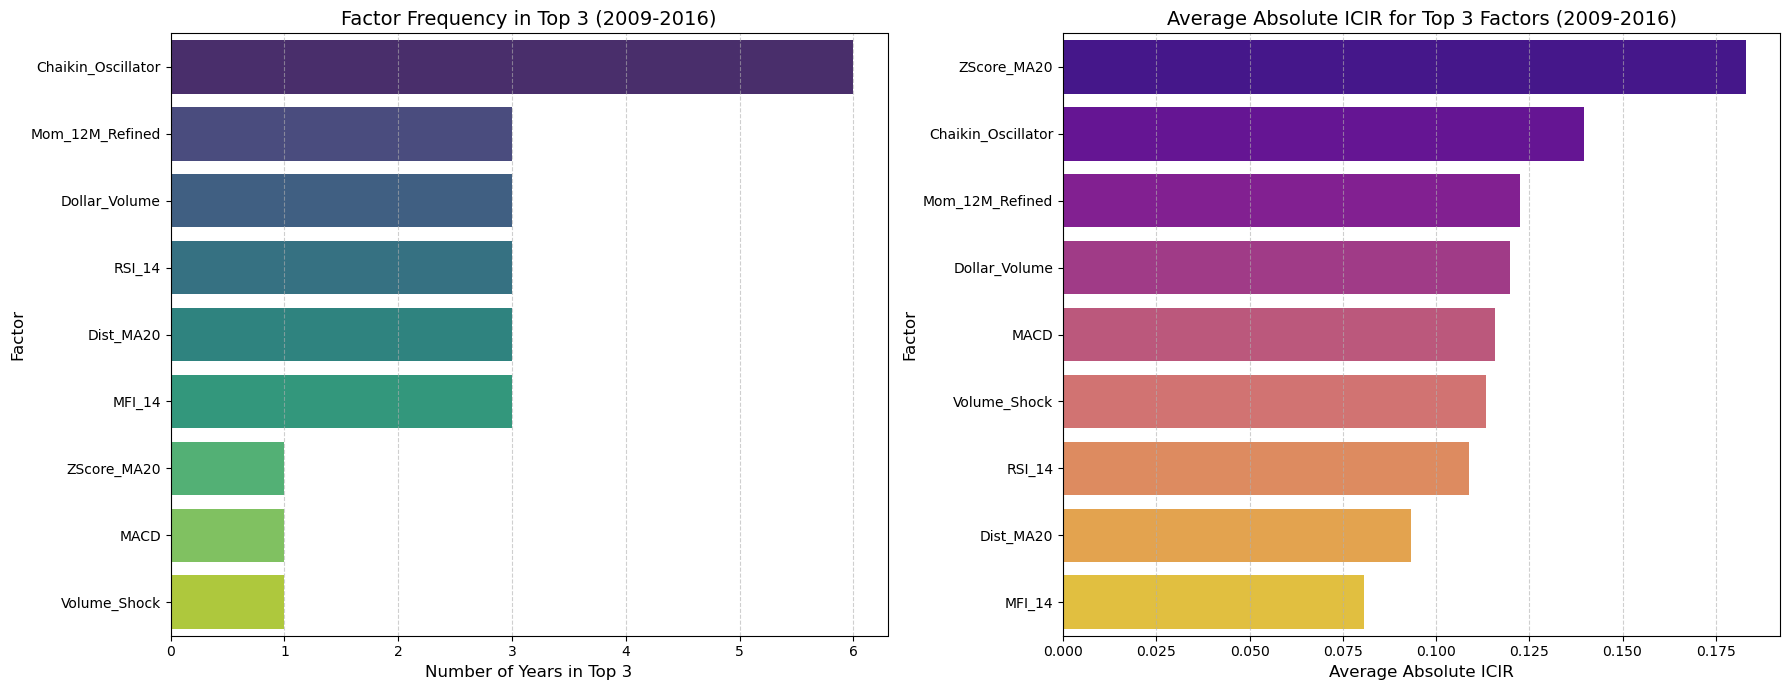

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Factor Frequency
sns.barplot(
    x='frequency',
    y='factor',
    data=summary_factors.sort_values('frequency', ascending=False),
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Factor Frequency in Top 3 (2009-2016)', fontsize=14)
axes[0].set_xlabel('Number of Years in Top 3', fontsize=12)
axes[0].set_ylabel('Factor', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# Plot 2: Average Absolute ICIR
sns.barplot(
    x='average_abs_ICIR',
    y='factor',
    data=summary_factors.sort_values('average_abs_ICIR', ascending=False),
    palette='plasma',
    ax=axes[1]
)
axes[1].set_title('Average Absolute ICIR for Top 3 Factors (2009-2016)', fontsize=14)
axes[1].set_xlabel('Average Absolute ICIR', fontsize=12)
axes[1].set_ylabel('Factor', fontsize=12)
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Factor Performance Across Years: Heatmap of Absolute ICIR

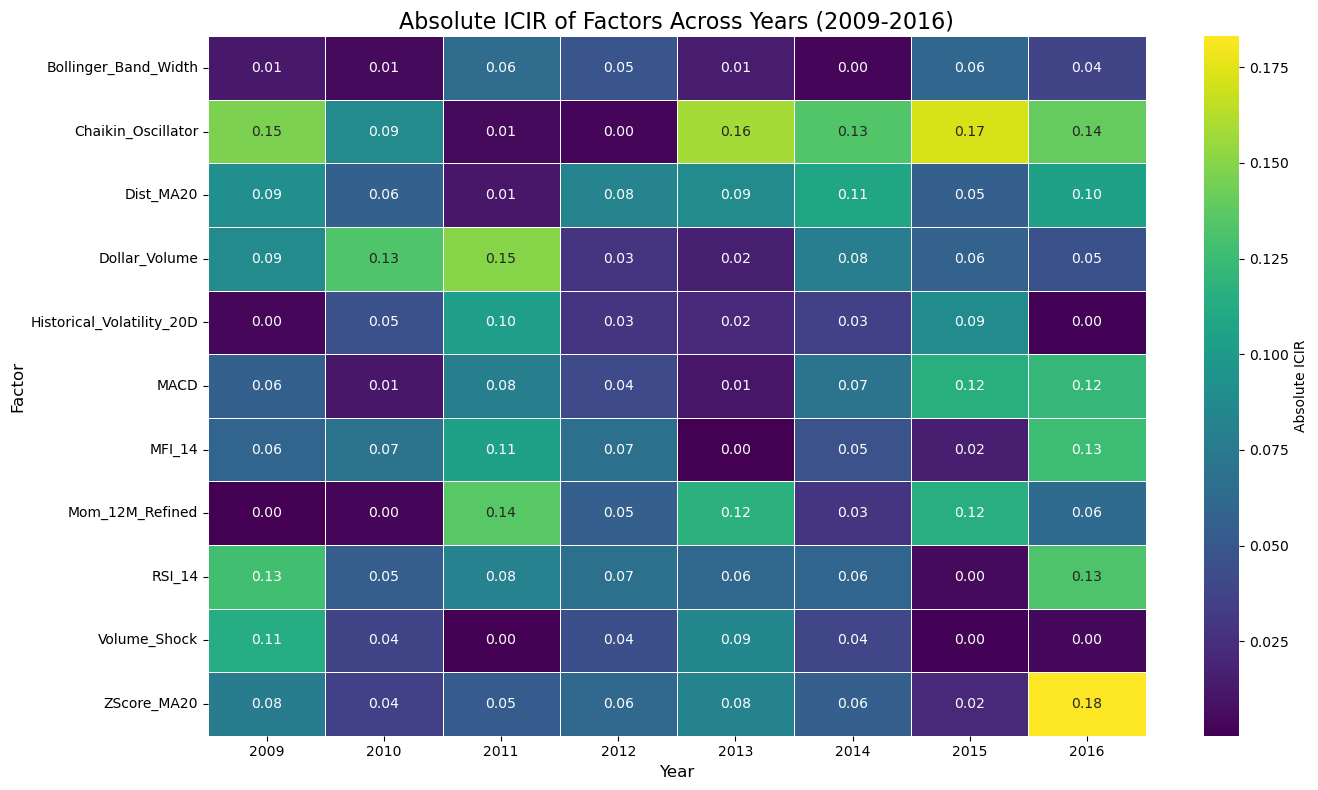

In [18]:
# Pivot the combined_icir_df to prepare for heatmap
# We want years as columns, factors as rows, and abs_ICIR as values
heatmap_data = combined_icir_df.pivot_table(
    index='factor',
    columns='year',
    values='abs_ICIR'
)

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    annot=True, # Show the values in the cells
    fmt=".2f",  # Format annotations to two decimal places
    cmap="viridis", # Choose a colormap
    linewidths=.5, # Add lines between cells
    cbar_kws={'label': 'Absolute ICIR'}
)

plt.title('Absolute ICIR of Factors Across Years (2009-2016)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Factor', fontsize=12)
plt.tight_layout()
plt.show()

### Composite Z-Score Calculation and Output per Year based on its own results

In [19]:
import os

# Create a directory to store the yearly composite z-score data based on each year's top 3 factors
composite_output_dir_dynamic = "yearly_composite_zscores_dynamic_factors"
os.makedirs(composite_output_dir_dynamic, exist_ok=True)

for year in years_to_analyze:
    print(f"Calculating composite z-score for year: {year} using its own top 3 factors...")

    # Load yearly factors data for the current year
    yearly_factors_filename = f"dow_10_factors_{year}.csv"
    yearly_factors = pd.read_csv(yearly_factors_filename)
    yearly_factors["date"] = pd.to_datetime(yearly_factors["date"])

    # Merge with forward_return for the current year from the pre-loaded 'df'
    yearly_merged_df = yearly_factors.merge(
        df[df['date'].dt.year == year][["date", "symbol", "forward_return"]],
        on=["date", "symbol"],
        how="left"
    )

    # Recompute z-scores for all factor columns for the current year
    for col in factor_cols:
        z_col = col + "_z"
        yearly_merged_df[z_col] = yearly_merged_df.groupby("date")[col].transform(
            lambda x: (x - x.mean()) / x.std(ddof=0)
        )
        yearly_merged_df[z_col] = yearly_merged_df[z_col].clip(-2, 2)

    # Get the top 3 factors for the *current year* from the pre-calculated top_factors_per_year
    top_3_factors_for_current_year = top_factors_per_year[top_factors_per_year['year'] == year]['factor'].tolist()

    # Get the mean IC for the current year for factor alignment
    # This uses the combined_icir_df which already holds mean ICs for each factor by year
    mean_ic_map_for_current_year = combined_icir_df[combined_icir_df['year'] == year].set_index('factor')['mean'].to_dict()

    aligned_z_cols_for_current_year = []
    for factor in top_3_factors_for_current_year:
        z_col = factor + "_z"
        aligned_col = factor + "_aligned_z"
        aligned_z_cols_for_current_year.append(aligned_col)

        # Align the factor's z-score based on its mean IC for the current year
        if factor in mean_ic_map_for_current_year and mean_ic_map_for_current_year[factor] < 0:
            yearly_merged_df[aligned_col] = -1 * yearly_merged_df[z_col]
        else:
            yearly_merged_df[aligned_col] = yearly_merged_df[z_col]

    # Calculate the composite z-score for the current year
    if aligned_z_cols_for_current_year: # Ensure there are factors to average
        yearly_merged_df["composite_zscore"] = yearly_merged_df[aligned_z_cols_for_current_year].mean(axis=1)
    else:
        yearly_merged_df["composite_zscore"] = np.nan # If no top factors were found

    # Prepare the DataFrame to be saved
    columns_to_save = ["date", "symbol", "forward_return", "composite_zscore"] + aligned_z_cols_for_current_year
    yearly_composite_output = yearly_merged_df[columns_to_save].copy()

    # Save to CSV
    output_filepath = os.path.join(composite_output_dir_dynamic, f"composite_zscore_dynamic_{year}.csv")
    yearly_composite_output.to_csv(output_filepath, index=False)
    print(f"Saved dynamic composite z-scores for {year} to {output_filepath}")

print("All yearly composite z-score files based on dynamic top factors have been generated and saved.")

Calculating composite z-score for year: 2009 using its own top 3 factors...
Saved dynamic composite z-scores for 2009 to yearly_composite_zscores_dynamic_factors\composite_zscore_dynamic_2009.csv
Calculating composite z-score for year: 2010 using its own top 3 factors...
Saved dynamic composite z-scores for 2010 to yearly_composite_zscores_dynamic_factors\composite_zscore_dynamic_2010.csv
Calculating composite z-score for year: 2011 using its own top 3 factors...
Saved dynamic composite z-scores for 2011 to yearly_composite_zscores_dynamic_factors\composite_zscore_dynamic_2011.csv
Calculating composite z-score for year: 2012 using its own top 3 factors...
Saved dynamic composite z-scores for 2012 to yearly_composite_zscores_dynamic_factors\composite_zscore_dynamic_2012.csv
Calculating composite z-score for year: 2013 using its own top 3 factors...
Saved dynamic composite z-scores for 2013 to yearly_composite_zscores_dynamic_factors\composite_zscore_dynamic_2013.csv
Calculating composit

In [20]:
import os

# Define the fixed factors for composite z-score calculation
fixed_factors_for_composite = ['Chaikin_Oscillator', 'ZScore_MA20', 'Mom_12M_Refined']

# Create a directory to store the yearly composite z-score data based on fixed factors
composite_output_dir_fixed = "yearly_composite_zscores_fixed_factors"
os.makedirs(composite_output_dir_fixed, exist_ok=True)

for year in years_to_analyze:
    print(f"Calculating composite z-score for year: {year} using fixed factors...")

    # Load yearly factors data for the current year
    yearly_factors_filename = f"dow_10_factors_{year}.csv"
    yearly_factors = pd.read_csv(yearly_factors_filename)
    yearly_factors["date"] = pd.to_datetime(yearly_factors["date"])

    # Merge with forward_return for the current year from the pre-loaded 'df'
    yearly_merged_df_fixed = yearly_factors.merge(
        df[df['date'].dt.year == year][["date", "symbol", "forward_return"]],
        on=["date", "symbol"],
        how="left"
    )

    # Recompute z-scores for all factor columns for the current year (needed for fixed factors too)
    for col in factor_cols:
        z_col = col + "_z"
        yearly_merged_df_fixed[z_col] = yearly_merged_df_fixed.groupby("date")[col].transform(
            lambda x: (x - x.mean()) / x.std(ddof=0)
        )
        yearly_merged_df_fixed[z_col] = yearly_merged_df_fixed[z_col].clip(-2, 2)

    # Get the mean IC for the current year for factor alignment
    # This uses the combined_icir_df which already holds mean ICs for each factor by year
    mean_ic_map_for_current_year_fixed = combined_icir_df[combined_icir_df['year'] == year].set_index('factor')['mean'].to_dict()

    aligned_z_cols_for_fixed_factors = []
    for factor in fixed_factors_for_composite:
        z_col = factor + "_z"
        aligned_col = factor + "_aligned_z"
        aligned_z_cols_for_fixed_factors.append(aligned_col)

        # Align the factor's z-score based on its mean IC for the current year
        if factor in mean_ic_map_for_current_year_fixed and mean_ic_map_for_current_year_fixed[factor] < 0:
            yearly_merged_df_fixed[aligned_col] = -1 * yearly_merged_df_fixed[z_col]
        else:
            yearly_merged_df_fixed[aligned_col] = yearly_merged_df_fixed[z_col]

    # Calculate the composite z-score for the current year using fixed factors
    if aligned_z_cols_for_fixed_factors: # Ensure there are factors to average
        yearly_merged_df_fixed["composite_zscore"] = yearly_merged_df_fixed[aligned_z_cols_for_fixed_factors].mean(axis=1)
    else:
        yearly_merged_df_fixed["composite_zscore"] = np.nan # If no fixed factors were found

    # Prepare the DataFrame to be saved
    columns_to_save_fixed = ["date", "symbol", "forward_return", "composite_zscore"] + aligned_z_cols_for_fixed_factors
    yearly_composite_output_fixed = yearly_merged_df_fixed[columns_to_save_fixed].copy()

    # Save to CSV
    output_filepath_fixed = os.path.join(composite_output_dir_fixed, f"composite_z_COZMOM_{year}.csv")
    yearly_composite_output_fixed.to_csv(output_filepath_fixed, index=False)
    print(f"Saved fixed composite z-scores for {year} to {output_filepath_fixed}")

print("All yearly composite z-score files based on fixed factors have been generated and saved.")

Calculating composite z-score for year: 2009 using fixed factors...
Saved fixed composite z-scores for 2009 to yearly_composite_zscores_fixed_factors\composite_z_COZMOM_2009.csv
Calculating composite z-score for year: 2010 using fixed factors...
Saved fixed composite z-scores for 2010 to yearly_composite_zscores_fixed_factors\composite_z_COZMOM_2010.csv
Calculating composite z-score for year: 2011 using fixed factors...
Saved fixed composite z-scores for 2011 to yearly_composite_zscores_fixed_factors\composite_z_COZMOM_2011.csv
Calculating composite z-score for year: 2012 using fixed factors...
Saved fixed composite z-scores for 2012 to yearly_composite_zscores_fixed_factors\composite_z_COZMOM_2012.csv
Calculating composite z-score for year: 2013 using fixed factors...
Saved fixed composite z-scores for 2013 to yearly_composite_zscores_fixed_factors\composite_z_COZMOM_2013.csv
Calculating composite z-score for year: 2014 using fixed factors...
Saved fixed composite z-scores for 2014 to

### Performance Metrics: Dynamic vs. Fixed Composite Z-Scores

In [24]:
import pandas as pd
import numpy as np
import os

composite_ic_results = []

for year in years_to_analyze:
    # --- Process Dynamic Composite Z-Scores ---
    dynamic_filepath = os.path.join(
        composite_output_dir_dynamic,
        f"composite_zscore_dynamic_{year}.csv"
    )

    if os.path.exists(dynamic_filepath):
        df_dynamic_composite = pd.read_csv(dynamic_filepath)
        df_dynamic_composite['date'] = pd.to_datetime(df_dynamic_composite['date'])

        daily_ic_dynamic = df_dynamic_composite.groupby('date').apply(
            lambda x: x[['composite_zscore', 'forward_return']].dropna().corr(method='spearman').iloc[0, 1]
            if len(x[['composite_zscore', 'forward_return']].dropna()) > 1 else np.nan
        )

        for dt, ic_val in daily_ic_dynamic.items():
            composite_ic_results.append({
                "year": year,
                "date": dt,
                "method": "Dynamic Top 3 Factors",
                "IC": ic_val
            })
    else:
        print(f"Warning: Dynamic composite z-score file not found for {year}: {dynamic_filepath}")

    # --- Process Fixed Composite Z-Scores ---
    fixed_filepath = os.path.join(
        composite_output_dir_fixed,
        f"composite_z_COZMOM_{year}.csv"
    )

    if os.path.exists(fixed_filepath):
        df_fixed_composite = pd.read_csv(fixed_filepath)
        df_fixed_composite['date'] = pd.to_datetime(df_fixed_composite['date'])

        daily_ic_fixed = df_fixed_composite.groupby('date').apply(
            lambda x: x[['composite_zscore', 'forward_return']].dropna().corr(method='spearman').iloc[0, 1]
            if len(x[['composite_zscore', 'forward_return']].dropna()) > 1 else np.nan
        )

        for dt, ic_val in daily_ic_fixed.items():
            composite_ic_results.append({
                "year": year,
                "date": dt,
                "method": "Fixed Factors",
                "IC": ic_val
            })
    else:
        print(f"Warning: Fixed composite z-score file not found for {year}: {fixed_filepath}")

composite_ic_df = pd.DataFrame(composite_ic_results)

# Calculate ICIR for each method and year
composite_icir_df = composite_ic_df.groupby(['year', 'method'])['IC'].agg(['mean', 'std']).reset_index()
composite_icir_df['ICIR'] = composite_icir_df['mean'] / composite_icir_df['std']
composite_icir_df['abs_ICIR'] = composite_icir_df['ICIR'].abs()

print("Composite Z-Score Performance Metrics (ICIR) by Year:")
display(composite_icir_df.sort_values(by=['year', 'abs_ICIR'], ascending=[True, False]))


Composite Z-Score Performance Metrics (ICIR) by Year:


,year,method,mean,std,ICIR,abs_ICIR
0,2009,Dynamic Top 3 Factors,0.047996,0.240070,0.199927,0.199927
1,2009,Fixed Factors,0.017628,0.285013,0.061851,0.061851
2,2010,Dynamic Top 3 Factors,0.027304,0.222566,0.122676,0.122676
3,2010,Fixed Factors,0.005960,0.265707,0.022431,0.022431
4,2011,Dynamic Top 3 Factors,0.038305,0.275015,0.139284,0.139284
5,2011,Fixed Factors,0.026513,0.269447,0.098396,0.098396
7,2012,Fixed Factors,0.029834,0.269949,0.110516,0.110516
6,2012,Dynamic Top 3 Factors,0.020336,0.266362,0.076345,0.076345
9,2013,Fixed Factors,0.042343,0.228831,0.185041,0.185041
8,2013,Dynamic Top 3 Factors,0.042634,0.232789,0.183143,0.183143


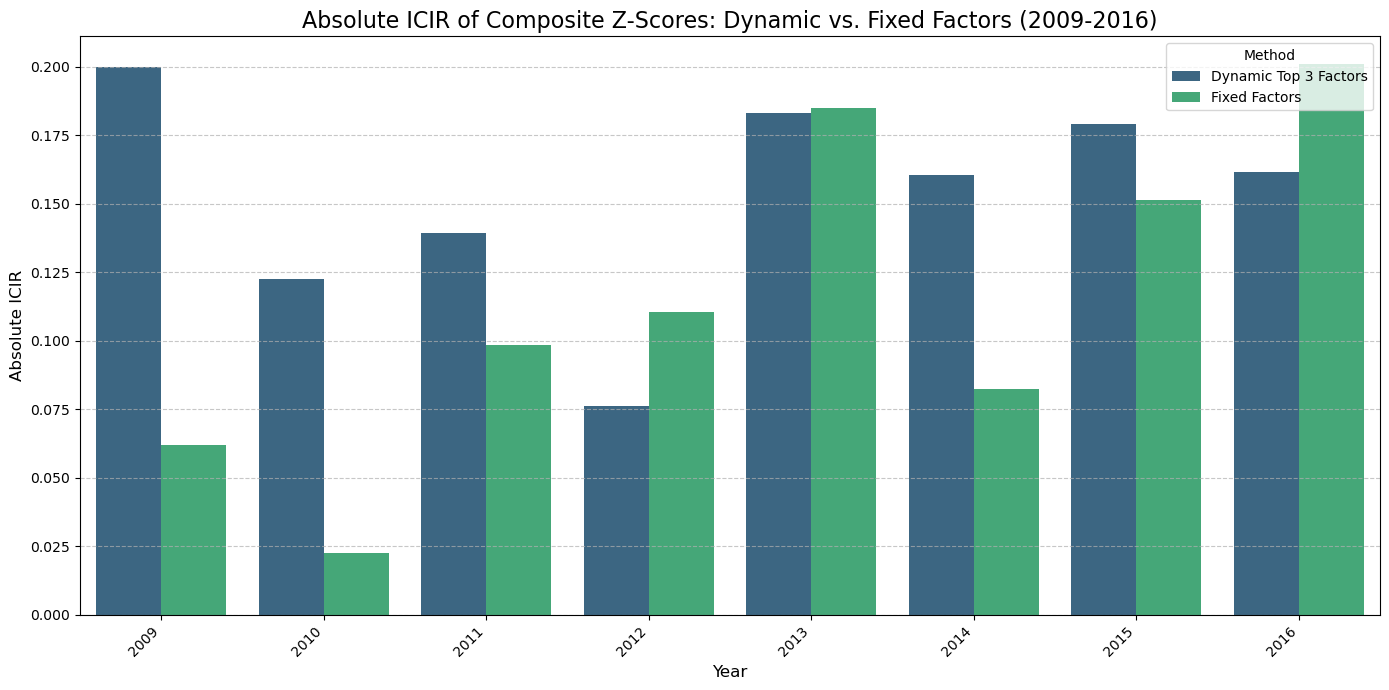

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.barplot(
    x='year',
    y='abs_ICIR',
    hue='method',
    data=composite_icir_df,
    palette='viridis'
)
plt.title('Absolute ICIR of Composite Z-Scores: Dynamic vs. Fixed Factors (2009-2016)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Absolute ICIR', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Method')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
